In [ ]:
import pandas as pd

: 

In [3]:
selected_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Fwd Packet Length Max",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Idle Mean",
    "Active Mean",
    "Protocol"
]


In [4]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("combined_dataset.csv")
df.columns = df.columns.str.strip()  # remove extra spaces

# Ensure numeric data and fill NaNs
df = df.fillna(0)

# Keep only selected features + label
df = df[selected_features + ["Label"]]

# Split features and target
X = df[selected_features]
y = df["Label"].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train XGBoost model
model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f" Model trained with selected features. Accuracy: {accuracy:.4f}")
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print results
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


C:\Users\amrut\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:14:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 Model trained with selected features. Accuracy: 0.9856
Accuracy : 0.9856
Precision: 0.9869
Recall   : 0.9905
F1 Score : 0.9887


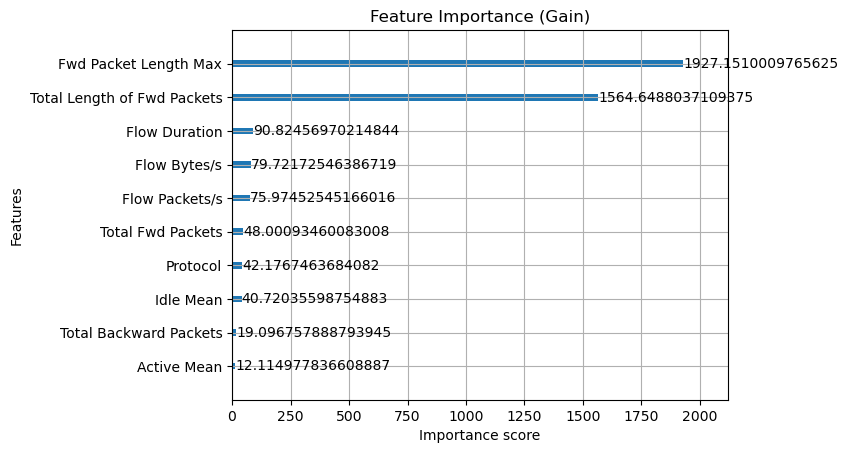

In [5]:
import xgboost as xgb
import matplotlib.pyplot as plt


xgb.plot_importance(model, importance_type='gain', title='Feature Importance (Gain)')
plt.show()


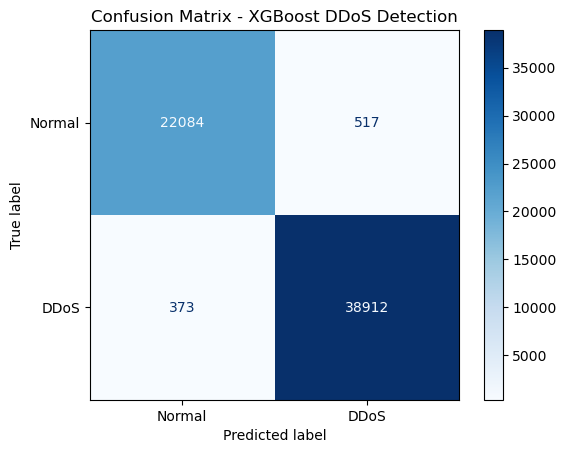

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "DDoS"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGBoost DDoS Detection")
plt.show()


In [ ]:
model.save_model("xgb_model.json")


: 